<a href="https://colab.research.google.com/github/Hozaifa-777/Project_Galaxy/blob/main/notebools/01_eda/baseline_model_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import lightgbm as lab

In [ ]:
data_star = pd.read_csv('/content/drive/MyDrive/مسابقة كاجل/train.csv')

In [ ]:
data_star.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [ ]:
data_star.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [ ]:
data_star.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [ ]:
data_star.shape

(577347, 12)

In [ ]:
data_star.isnull().sum()

,0
id,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0
spectral_type,0


In [ ]:
data_star['class'].sort_values()

,class
0,GALAXY
344729,GALAXY
344728,GALAXY
344726,GALAXY
344724,GALAXY
...,...
153816,STAR
342256,STAR
491851,STAR
55916,STAR


In [ ]:
data_sample = data_star.sample(n=10000, random_state=42)

Text(0, 0.5, 'Redshift')

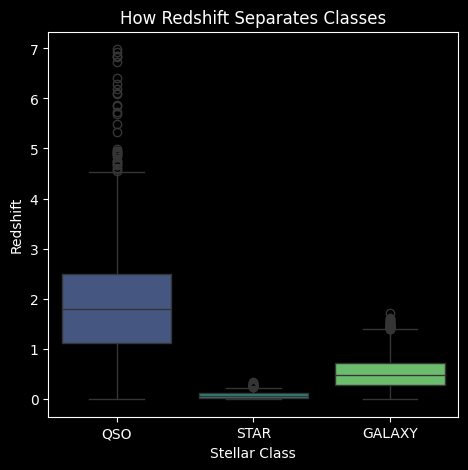

In [ ]:
from typing import Text
plt.style.use('dark_background')
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=data_sample, x='class', y='redshift', hue='class',palette='viridis')
plt.title('How Redshift Separates Classes')
plt.xlabel('Stellar Class')
plt.ylabel('Redshift')

Text(0, 0.5, 'Redshift')

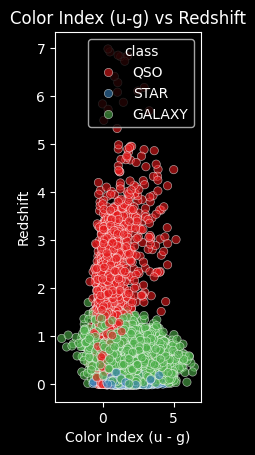

In [ ]:
data_sample['u_g'] = data_sample['u'] - data_sample['g']
plt.subplot(1, 3, 2)
sns.scatterplot(data=data_sample, x='u_g', y='redshift', hue='class', alpha=0.6, palette='Set1')
plt.title('Color Index (u-g) vs Redshift')
plt.xlabel('Color Index (u - g)')
plt.ylabel('Redshift')

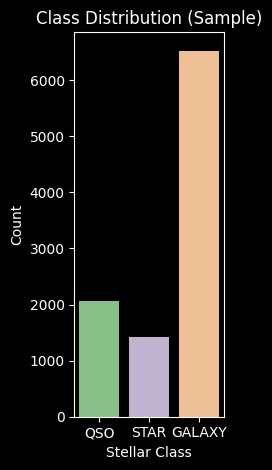

In [ ]:
plt.subplot(1, 3, 3)
sns.countplot(data=data_sample, x='class', hue='class',palette='Accent')
plt.title('Class Distribution (Sample)')
plt.xlabel('Stellar Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
print("--- Distribution of Spectral Type across Classes ---")
spectral_table = pd.crosstab(data_star['spectral_type'], data_star['class'], margins=True)
display(spectral_table)

print("\n" + "="*50 + "\n")

print("--- Distribution of Galaxy Population across Classes ---")
population_table = pd.crosstab(data_star['galaxy_population'], data_star['class'], margins=True)
display(population_table)

--- Distribution of Spectral Type across Classes ---


class,GALAXY,QSO,STAR,All
spectral_type,,,,
A/F,24240,61514,36368,122122
G/K,61627,20921,25998,108546
M,288023,3889,11411,303323
O/B,3590,30819,8947,43356
All,377480,117143,82724,577347




--- Distribution of Galaxy Population across Classes ---


class,GALAXY,QSO,STAR,All
galaxy_population,,,,
Blue_Cloud,88962,108274,60546,257782
Red_Sequence,288518,8869,22178,319565
All,377480,117143,82724,577347


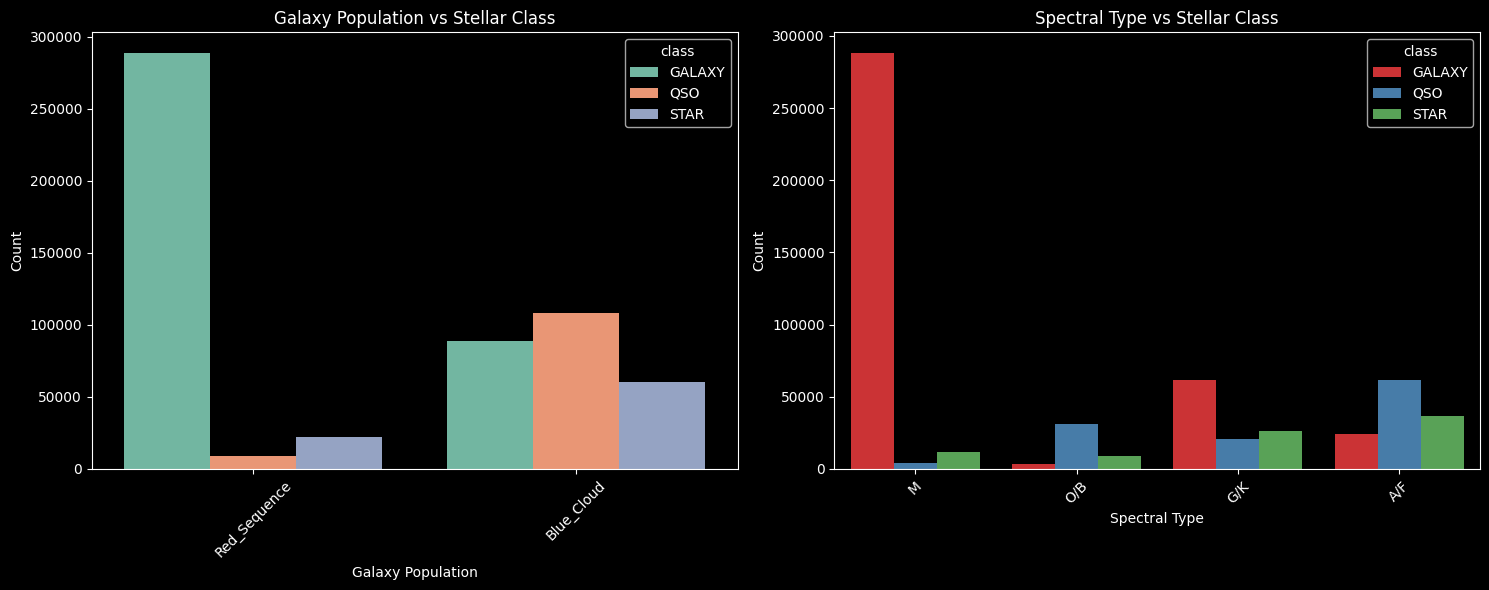

In [ ]:
plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)

sns.countplot(data=data_star, x='galaxy_population', hue='class', palette='Set2')
plt.title('Galaxy Population vs Stellar Class')
plt.xticks(rotation=45)
plt.xlabel('Galaxy Population')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(data=data_star, x='spectral_type', hue='class', palette='Set1')
plt.title('Spectral Type vs Stellar Class')
plt.xticks(rotation=45)
plt.xlabel('Spectral Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
data_encoded = data_star.copy()

le_spectral = LabelEncoder()
data_encoded['spectral_type'] = le_spectral.fit_transform(data_encoded['spectral_type'].astype(str))

le_population = LabelEncoder()
data_encoded['galaxy_population'] = le_population.fit_transform(data_encoded['galaxy_population'].astype(str))

le_class = LabelEncoder()
data_encoded['class'] = le_class.fit_transform(data_encoded['class'].astype(str))

data_encoded.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,2,1,0
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,2,1,0
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,3,0,1
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,2,1,0
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,2,1,0


In [ ]:
print(dict(zip(le_class.classes_, le_class.transform(le_class.classes_))))
print(dict(zip(le_population.classes_, le_population.transform(le_population.classes_))))
print(dict(zip(le_spectral.classes_, le_spectral.transform(le_spectral.classes_))))

{'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}
{'Blue_Cloud': np.int64(0), 'Red_Sequence': np.int64(1)}
{'A/F': np.int64(0), 'G/K': np.int64(1), 'M': np.int64(2), 'O/B': np.int64(3)}


In [ ]:
data_encoded.corr()['class'].sort_values()

,class
galaxy_population,-0.490872
u,-0.385667
spectral_type,-0.368430
g,-0.285010
r,-0.049845
id,-0.000874
delta,0.017359
alpha,0.033585
redshift,0.077758
i,0.107635


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2046
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 10
[LightGBM] [Info] Start training from score -0.424925
[LightGBM] [Info] Start training from score -1.595051
[LightGBM] [Info] Start training from score -1.942935
Accuracy: 0.96383


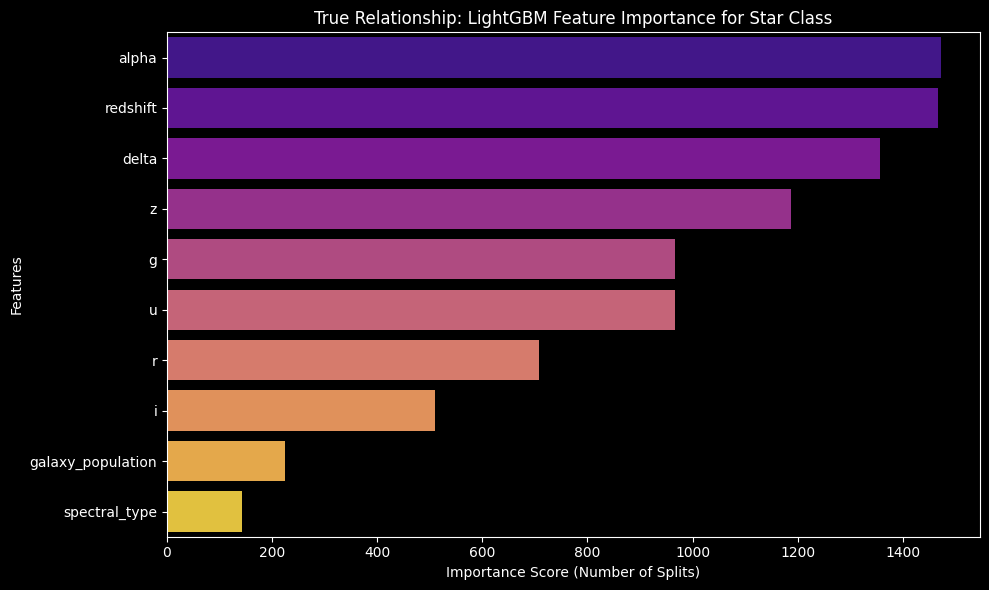

In [ ]:
X = data_encoded.drop(columns=['id', 'class'])
y = data_encoded['class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


model = lab.LGBMClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.5f}")

feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X.columns)), columns=['Value','Feature'])

plt.figure(figsize=(10, 6))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False), hue="Feature", legend=False, palette="plasma")
plt.title('True Relationship: LightGBM Feature Importance for Star Class')
plt.xlabel('Importance Score (Number of Splits)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
data_encoded['u_g'] = data_encoded['u'] - data_encoded['g']
data_encoded['g_r'] = data_encoded['g'] - data_encoded['r']
data_encoded['r_i'] = data_encoded['r'] - data_encoded['i']
data_encoded['i_z'] = data_encoded['i'] - data_encoded['z']

data_encoded['u_r'] = data_encoded['u'] - data_encoded['r']
data_encoded['g_i'] = data_encoded['g'] - data_encoded['i']

data_encoded['redshift_r'] = data_encoded['redshift'] * data_encoded['r']

X_advanced = data_encoded.drop(columns=['id', 'class'])
y_advanced = data_encoded['class']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(
X_advanced, y_advanced, test_size=0.2, random_state=42, stratify=y_advanced
)

model_adv = lab.LGBMClassifier(random_state=42, n_estimators=1000, learning_rate=0.07)
model_adv.fit(X_train_adv, y_train_adv)

y_pred_adv = model_adv.predict(X_val_adv)
advanced_accuracy = accuracy_score(y_val_adv, y_pred_adv)

print(f"Baseline Accuracy: {accuracy * 100:.5f}%")
print(f" Advanced Feature Engineering Accuracy: {advanced_accuracy * 100:.5f}%")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.087683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3831
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 17
[LightGBM] [Info] Start training from score -0.424925
[LightGBM] [Info] Start training from score -1.595051
[LightGBM] [Info] Start training from score -1.942935
Baseline Accuracy: 96.38261%
 Advanced Feature Engineering Accuracy: 96.59479%


In [ ]:
data_encoded['u_g'] = data_encoded['u'] - data_encoded['g']
data_encoded['g_r'] = data_encoded['g'] - data_encoded['r']
data_encoded['r_i'] = data_encoded['r'] - data_encoded['i']
data_encoded['i_z'] = data_encoded['i'] - data_encoded['z']

data_encoded['u_r'] = data_encoded['u'] - data_encoded['r']
data_encoded['g_i'] = data_encoded['g'] - data_encoded['i']

data_encoded['redshift_r'] = data_encoded['redshift'] * data_encoded['r']

X_advanced = data_encoded.drop(columns=["id", "class"])
y_advanced = data_encoded["class"]


X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(
X_advanced, y_advanced, test_size=0.2, random_state=42, stratify=y_advanced
)

base_model = lab.LGBMClassifier(random_state=42)

param_distributions = {
"learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
"n_estimators": [100, 300, 500, 800, 1000],
"max_depth": [5, 7, 10, -1],
"num_leaves": [20, 31, 50, 70, 127],
"subsample": [0.7, 0.8, 0.9, 1.0],
}


n_iter=10

cv=5

random_search = RandomizedSearchCV(
estimator=base_model,
param_distributions=param_distributions,
n_iter=10,
cv=5,
scoring="accuracy",
random_state=42,
n_jobs=-1,
verbose=1,
)

print(" Starting Randomized Search... Please wait a moment.")

random_search.fit(X_train_adv, y_train_adv)

print("\n" + "=" * 40)
print("Best Hyperparameters Found:", random_search.best_params_)
print(f"Best CV Training Accuracy: {random_search.best_score_ * 100:.5f}%")
print("=" * 40 + "\n")


best_model = random_search.best_estimator_
y_val_pred = best_model.predict(X_val_adv)
final_val_accuracy = accuracy_score(y_val_adv, y_val_pred)

print(
f"Final Validation Accuracy with Best Model: {final_val_accuracy * 100:.5f}%"
)

 Starting Randomized Search... Please wait a moment.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3831
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 17
[LightGBM] [Info] Start training from score -0.424925
[LightGBM] [Info] Start training from score -1.595051
[LightGBM] [Info] Start training from score -1.942935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 